# Loss Curves for Neural Networks
**Objectives**
- Analyze and interpret training and testing loss curves for tabular data.
- Identify common training issues such as overfitting, underfitting, and instability.
- Experiment with model hyperparameters and training parameters to improve performance.


---

The **UCI Adult Income dataset** is a tabular dataset used for binary classification tasks. The goal is to predict whether an individual's income exceeds $50,000 per year based on census data.

**Details**:
- **Features:** 14 attributes (e.g., age, education, occupation).
- **Target:** Binary class (income >50K or <=50K).
- **Size:** 32,561

**Main Tasks**:
1. Load and preprocess the dataset.
2. Split it into a training and test set.
3. Train a neural network and analyze the training/test loss curves.
4. Perform experiments to understand how model capacity and learning rate impact performance.


----

## Part 1: Data Preparation

Objectives:
1. Load the dataset using `pandas`.
2. Split the data into a training and test set (say, 90%/10%)
3. Prepare data for training and inference by adequately handling missing values, categorical features, and normalizing the data.



In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]

data = pd.read_csv(url, names=columns, sep=',\s*', engine='python', na_values="NA")

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_60648/3364657076.py:9: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(url, names=columns, sep=',\s*', engine='python', na_values="NA")


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [3]:
data.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


x

In [4]:
for column in data:
    print(column)
    print(data[column].unique())

age
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
fnlwgt
[ 77516  83311 215646 ...  34066  84661 257302]
education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
education-num
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-

In [5]:
import plotly.express as px

for col in data.columns:
    counts = data[col].value_counts().reset_index()
    counts.columns = [col, "count"]

    fig = px.bar(counts, x=col, y="count", title=f"Value counts for {col}")
    fig.show()

Nu testar jag att bygga en pipeline med SciKitLearns Pipeline.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
categorical_features: list[str] = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
numeric_features: list[str] = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


In [9]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

In [10]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

Här ger jag upp att använda Pipeline och går tillbaka till att fixa kolumner manuellt...  
Jag väljer att droppa några kategoriska kolumner med många småvärden och behålla dem som jag tänker har mest påverkan på inkomsten genom att göra one hot.  
De som går lätt att göra binära gör jag om till 0 och 1. Några andra värden klumpar jag ihop och gör one hot.  
Numeriska kolumner skalas genom att dividera med maxvärde.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
keep_columns: list[str] = ["age", "education-num", "marital-status", "occupation", "sex", "capital-gain", "capital-loss", "hours-per-week", "income"]
df = data[keep_columns].copy()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   education-num   32561 non-null  int64 
 2   marital-status  32561 non-null  object
 3   occupation      32561 non-null  object
 4   sex             32561 non-null  object
 5   capital-gain    32561 non-null  int64 
 6   capital-loss    32561 non-null  int64 
 7   hours-per-week  32561 non-null  int64 
 8   income          32561 non-null  object
dtypes: int64(5), object(4)
memory usage: 2.2+ MB


In [14]:
df["marital-status"] = df["marital-status"].apply(lambda val: val if val in ["Married-civ-spouse", "Never-married"] else "other-marital-status")
df["marital-status"].value_counts()



marital-status
Married-civ-spouse      14976
Never-married           10683
other-marital-status     6902
Name: count, dtype: int64

In [15]:
categorical_columns = ["marital-status", "occupation"]

for column in categorical_columns:
    for val in set(df[column].values):
        onehotencode = [1 if x == val else 0 for x in df[column]]
        df[val] = onehotencode

df = df.drop(columns=categorical_columns)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   32561 non-null  int64 
 1   education-num         32561 non-null  int64 
 2   sex                   32561 non-null  object
 3   capital-gain          32561 non-null  int64 
 4   capital-loss          32561 non-null  int64 
 5   hours-per-week        32561 non-null  int64 
 6   income                32561 non-null  object
 7   Married-civ-spouse    32561 non-null  int64 
 8   Never-married         32561 non-null  int64 
 9   other-marital-status  32561 non-null  int64 
 10  Machine-op-inspct     32561 non-null  int64 
 11  Tech-support          32561 non-null  int64 
 12  Craft-repair          32561 non-null  int64 
 13  Priv-house-serv       32561 non-null  int64 
 14  Exec-managerial       32561 non-null  int64 
 15  Prof-specialty        32561 non-null

In [16]:
df = df.rename(columns={"?": "unknown-occupation"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   32561 non-null  int64 
 1   education-num         32561 non-null  int64 
 2   sex                   32561 non-null  object
 3   capital-gain          32561 non-null  int64 
 4   capital-loss          32561 non-null  int64 
 5   hours-per-week        32561 non-null  int64 
 6   income                32561 non-null  object
 7   Married-civ-spouse    32561 non-null  int64 
 8   Never-married         32561 non-null  int64 
 9   other-marital-status  32561 non-null  int64 
 10  Machine-op-inspct     32561 non-null  int64 
 11  Tech-support          32561 non-null  int64 
 12  Craft-repair          32561 non-null  int64 
 13  Priv-house-serv       32561 non-null  int64 
 14  Exec-managerial       32561 non-null  int64 
 15  Prof-specialty        32561 non-null

In [17]:
df["sex"] = df["sex"].apply(lambda val: 1 if val == "Female" else 0)
df["sex"].value_counts()

sex
0    21790
1    10771
Name: count, dtype: int64

In [18]:
df["income"] = df["income"].apply(lambda val: 1 if val == ">50K" else 0)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   32561 non-null  int64
 1   education-num         32561 non-null  int64
 2   sex                   32561 non-null  int64
 3   capital-gain          32561 non-null  int64
 4   capital-loss          32561 non-null  int64
 5   hours-per-week        32561 non-null  int64
 6   income                32561 non-null  int64
 7   Married-civ-spouse    32561 non-null  int64
 8   Never-married         32561 non-null  int64
 9   other-marital-status  32561 non-null  int64
 10  Machine-op-inspct     32561 non-null  int64
 11  Tech-support          32561 non-null  int64
 12  Craft-repair          32561 non-null  int64
 13  Priv-house-serv       32561 non-null  int64
 14  Exec-managerial       32561 non-null  int64
 15  Prof-specialty        32561 non-null  int64
 16  Adm-

Alla kolumner är numeriska, dags att göra train/test split

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="income")
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(29304, 24)
(29304,)
(3257, 24)
(3257,)


Skala värden till mellan 0 och 1.

In [21]:
from numpy import abs

for column in X_train.columns:
    max_value = max(abs(X_train[column]))

    X_train[column] = X_train[column] / max_value
    X_test[column] = X_test[column] / max_value

In [22]:
print("X_train")
for col in X_train.columns:
    print(f"{col} {X_train[col].max()}")

print()
print("X_test")
for col in X_test.columns:
    print(f"{col} {X_test[col].max()}")

X_train
age 1.0
education-num 1.0
sex 1.0
capital-gain 1.0
capital-loss 1.0
hours-per-week 1.0
Married-civ-spouse 1.0
Never-married 1.0
other-marital-status 1.0
Machine-op-inspct 1.0
Tech-support 1.0
Craft-repair 1.0
Priv-house-serv 1.0
Exec-managerial 1.0
Prof-specialty 1.0
Adm-clerical 1.0
Handlers-cleaners 1.0
Sales 1.0
Other-service 1.0
Transport-moving 1.0
Armed-Forces 1.0
unknown-occupation 1.0
Protective-serv 1.0
Farming-fishing 1.0

X_test
age 1.0
education-num 1.0
sex 1.0
capital-gain 1.0
capital-loss 0.587465564738292
hours-per-week 1.0
Married-civ-spouse 1.0
Never-married 1.0
other-marital-status 1.0
Machine-op-inspct 1.0
Tech-support 1.0
Craft-repair 1.0
Priv-house-serv 1.0
Exec-managerial 1.0
Prof-specialty 1.0
Adm-clerical 1.0
Handlers-cleaners 1.0
Sales 1.0
Other-service 1.0
Transport-moving 1.0
Armed-Forces 1.0
unknown-occupation 1.0
Protective-serv 1.0
Farming-fishing 1.0


Omvandla till tensorer:

In [24]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [25]:
torch.cuda.is_available()

True

In [26]:
import numpy as np

X_train = torch.from_numpy(np.array(X_train)).type(torch.FloatTensor)
y_train = torch.from_numpy(np.array(y_train)).type(torch.FloatTensor).reshape([-1,1])

X_test = torch.from_numpy(np.array(X_test)).type(torch.FloatTensor)
y_test = torch.from_numpy(np.array(y_test)).type(torch.FloatTensor).reshape([-1,1])

In [27]:
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

In [28]:
training_set = list(zip(X_train, y_train))             # lägg ihop träningsdatan så att vi direkt kan skicka in i dataloader
test_set = list(zip(X_test, y_test))                   # ditto för testdatan

---

## Part 2: Build and Train the Model

**Initial Model Architecture**:


- *Input layer:* Size matches the number of features after encoding.
- *Hidden layers:*
  - Hidden Layer 1: 8 units, ReLU activation.
  - Hidden Layer 2: 8 units, ReLU activation.
- *Output layer:* 1 unit (binary classification), Sigmoid activation.


**Loss Function and Optimizer**:
- Loss: Binary Cross-Entropy Loss (`BCELoss`).
- Optimizer: SGD with a learning rate of 0.001.

**Training**:
- Train the model for 20 epochs.
- Record (store) the training and test losses at each epoch.


In [29]:
# your code here
# hint: recall how we did this previously
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import SGD
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

input_size = 24
epochs = 20
learning_rate = 0.001
batch_size = 16

In [30]:

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 1)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
                  
        return x

In [31]:
model = NeuralNetwork(input_size)

In [32]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


#model = NeuralNetwork(input_size)
model = model.to(device)                                  # förbered modellen för GPU

optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.BCELoss()

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []

for i in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    model.eval()
    
    y_true = y_test
    input_features = X_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)


---

## Part 3: Visualize and Interpret Loss Curves

**Tasks**:
1. Plot the training and test loss curves.
2. Answer the following questions:
   - Is the model underfitting, overfitting, or neither? Provide evidence.
   - If overfitting occurs, at what epoch does it begin?
   - What can you infer about the model's performance from the loss curves?

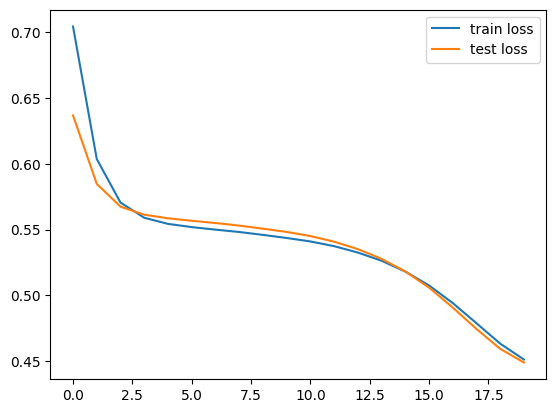

In [33]:
# your code here
# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss')
plt.legend()

plt.show()#

**Svar:**  
Modellen ser inte ut att varken vara över- eller underanpassad. Kurvorna för train och test loss följer varandra, och modellen presterar ungefär lika bra på bägge.  
Det sker en marginell förbättring över dessa tjugo epoker och den ser inte ut att plana ut, så man kan misstänka att den skulle kunna tjäna på att tränas längre, alternativt ha en högre learning rate.

---

## Part 4: Experimentation with Hyperparameters

**Experiment**: Varying model capacity
- Now train models with different hidden layer sizes (width & depth):
  - **Smaller model:** 
    - Try architectures will LESS representation capacity than we had initially
  - **Larger model:** 
    - Try architectures will MORE representation capacity than we had initially

- Train each of those architectures, with the same initial learning rate, 20 epochs each and plot their loss curves.

**Questions:**
1. How does changing the model size affect training and test loss?
2. What interesting findings have you found? Prepare to present and share with your classmates (just show the loss curves and explain your findings).

In [34]:
# your code here

class NeuralNetwork_2(nn.Module):
    def __init__(self, input_size: int, num_layers: int, num_neurons: int):
        super(NeuralNetwork_2, self).__init__()
        self.fc0 = nn.Linear(input_size, out_features=num_neurons)
        self.fc_m = nn.Linear(num_neurons, num_neurons)
        self.fc_out= nn.Linear(num_neurons, 1)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()
        self.num_layers = num_layers

    def forward(self, x):
        
        x = self.relu(self.fc0(x))
        for m in range(self.num_layers):
            x = self.relu(self.fc_m(x))
        
        x = self.sigmoid(self.fc_out(x))
                  
        return x
    # ----------------------------------------------------------------------------------------------------------------
    #    initera modell, loss_function, optimizer & dataloader
def run_and_show_model_performance(input_size: int=24, num_layers: int=2, num_neurons: int=8, epochs: int=20, learning_rate: float=0.001) -> None:

    model = NeuralNetwork_2(input_size, num_layers, num_neurons)
    model = model.to(device)                                  # förbered modellen för GPU

    optimizer = SGD(model.parameters(), lr = learning_rate)
    loss_function = torch.nn.BCELoss()

    train_dataloader = DataLoader(training_set,                 
                                batch_size = batch_size,       
                                shuffle=True)


    # ----------------------------------------------------------------------------------------------------------------
    #    träna



    batch_train_losses = []

    epoch_train_losses = []
    epoch_evaluation_losses = []

    for i in range(epochs):
        
        model.train()

        running_loss = 0
        
        for batch in train_dataloader:
            
            y_true = batch[1]
            input_features = batch[0]
            
            y_pred=model(input_features)
            loss=loss_function(y_pred, y_true)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            batch_loss = loss.item()
            batch_train_losses.append(batch_loss)
        
        epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
        epoch_train_losses.append(epoch_average_loss)

    # ----------------------------------------------------------------------------------------------------------------
    #   evalueringssektion 

        model.eval()
        
        y_true = y_test
        input_features = X_test
        
        y_pred = model(input_features)
        loss = loss_function(y_pred, y_true)
        
        evaluation_loss = loss.item()
        epoch_evaluation_losses.append(evaluation_loss)
        #   plotta resultat 

    plt.plot(epoch_train_losses, label = 'train loss')
    plt.plot(epoch_evaluation_losses, label = 'test loss')
    plt.legend()

    plt.show()#


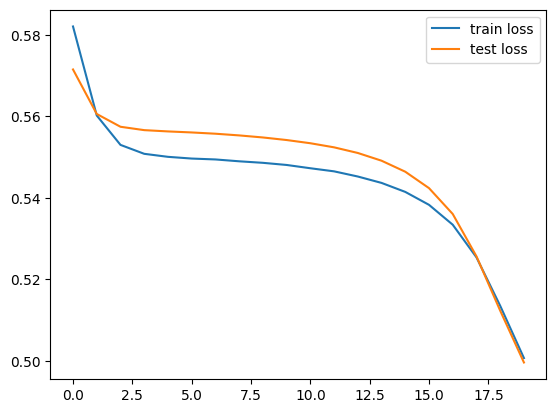

In [35]:
run_and_show_model_performance(num_layers=3, num_neurons=8)

Lossen faller av dramatiskt i början, sedan kommer en platå innan den till sist faller dramatiskt igen. Jag noterar att den dock är högre än tidigare.

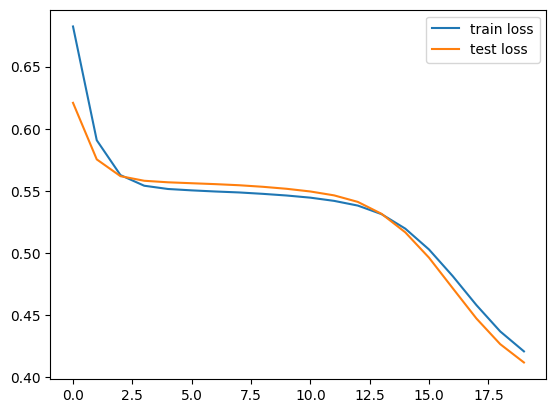

In [36]:
run_and_show_model_performance(num_layers=2, num_neurons=12)

Ingen större skillnad mot tre lager och åtta neuroner.

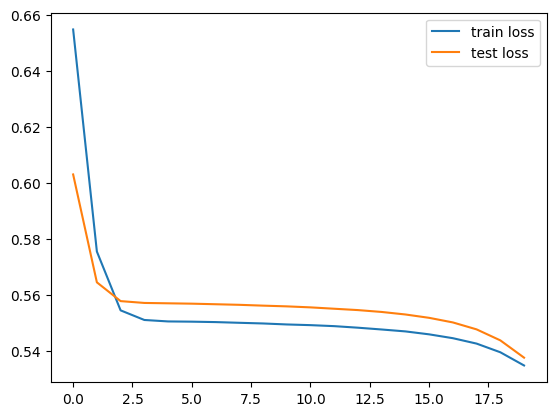

In [37]:
run_and_show_model_performance(num_layers=4, num_neurons=24)

Här får jag en typisk hockeyklubba, men kommer ändå inte ner i lika låg loss som tidigare, trots dubbelt så många lager och två och en halv gånger så många neuroner.

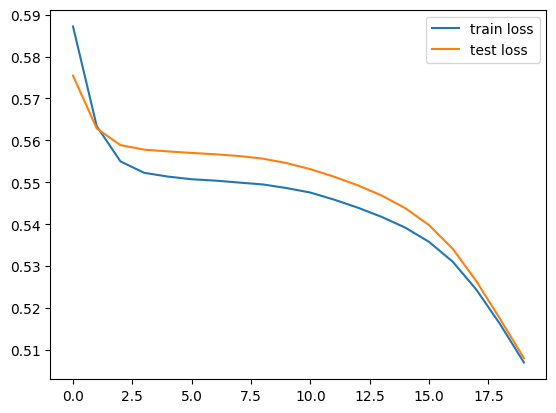

In [45]:
run_and_show_model_performance(num_layers=2, num_neurons=4)

En mindre modell med endast fyra neuroner presterar ungefär som den största modellen. Det verkar alltså inte vara antalet lager/neuroner som påverkar resultatet.

---
## Part 5: Experimentation with learning rate


**Experiment**: Periodic reduction of learning rate
- During class we learned that dropping the learning rate, after a period of training, could lead to better results. Can we try to replicate that?

**Question:**
1. Did you succeed? If so, why did it work?


In [42]:
# your code here

def run_and_show_model_performance_with_lowered_lri(input_size: int=24, num_layers: int=2, num_neurons: int=8, epochs: int=20, learning_rate: float=1, first_lr_drop: int=5, second_lr_drop: int=10, third_lr_drop: int=15) -> None:

    model = NeuralNetwork_2(input_size, num_layers, num_neurons)
    model = model.to(device)                                  # förbered modellen för GPU

    optimizer = SGD(model.parameters(), lr = learning_rate)
    loss_function = torch.nn.BCELoss()

    train_dataloader = DataLoader(training_set,                 
                                batch_size = batch_size,       
                                shuffle=True)


    # ----------------------------------------------------------------------------------------------------------------
    #    träna



    batch_train_losses = []

    epoch_train_losses = []
    epoch_evaluation_losses = []

    for i in range(epochs):
        
        model.train()

        running_loss = 0
        
        for batch in train_dataloader:
            
            y_true = batch[1]
            input_features = batch[0]
            
            y_pred=model(input_features)
            loss=loss_function(y_pred, y_true)
            loss.backward()
            if i == first_lr_drop:
                optimizer = SGD(model.parameters(), lr = learning_rate / 10)
            elif i == second_lr_drop:
                optimizer = SGD(model.parameters(), lr = learning_rate / 100)
            elif i == third_lr_drop:
                optimizer = SGD(model.parameters(), lr = learning_rate / 1000)
            optimizer.step()
            optimizer.zero_grad()
            
            batch_loss = loss.item()
            batch_train_losses.append(batch_loss)
        
        epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
        epoch_train_losses.append(epoch_average_loss)

    # ----------------------------------------------------------------------------------------------------------------
    #   evalueringssektion 

        model.eval()
        
        y_true = y_test
        input_features = X_test
        
        y_pred = model(input_features)
        loss = loss_function(y_pred, y_true)
        
        evaluation_loss = loss.item()
        epoch_evaluation_losses.append(evaluation_loss)
        #   plotta resultat 

    plt.plot(epoch_train_losses, label = 'train loss')
    plt.plot(epoch_evaluation_losses, label = 'test loss')
    plt.legend()

    plt.show()#


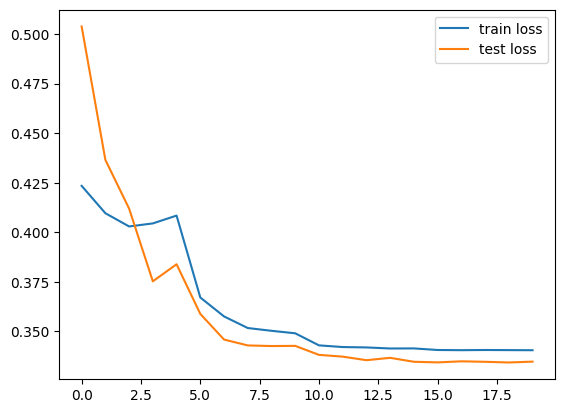

In [43]:
run_and_show_model_performance_with_lowered_lri()

**Svar:**  
Nu sänker jag learning rate vid epok 5, 10 och 15 från 1 till 0,1, 0,01, och till sist 0,001.  
Jag får en lägre loss än tidigare, men det verkar som att jag kanske sänker lr lite för tidigt. 

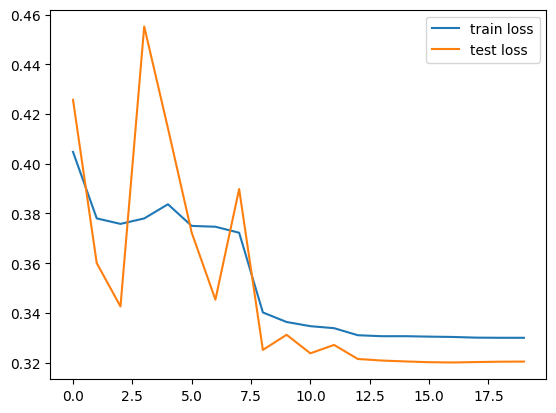

In [46]:
run_and_show_model_performance_with_lowered_lri(first_lr_drop=8, second_lr_drop=12, third_lr_drop=17)

Lägsta lossen hittills, och äntligen lite annat utseende på kurvan!

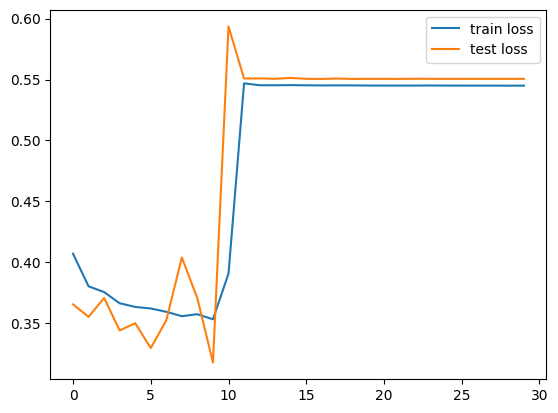

In [47]:
run_and_show_model_performance_with_lowered_lri(epochs=30, first_lr_drop=12, second_lr_drop=18, third_lr_drop=24)

Denna gång körde modellen helt ur spår precis innan jag sänkte lr!

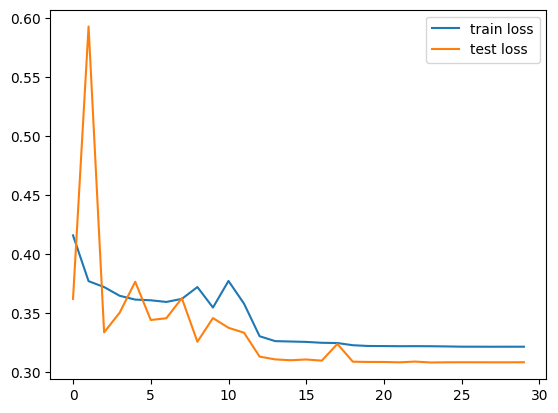

In [48]:
run_and_show_model_performance_with_lowered_lri(epochs=30, first_lr_drop=12, second_lr_drop=18, third_lr_drop=24)

Och här hade den tur och höll sig på banan med samma parametrar.  
Min teori är att det är svårt att få lägre loss än strax över 0,3 med den datan jag använder, och att det inte är en fråga om learning rate eller storlek på modellen.